In [1]:
import pandas as pd
import joblib

dataset = "creditcard.csv"

cards = pd.read_csv(dataset) 
cards.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
cards.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
cards.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
cards.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
corr_matrix = cards.corr("spearman")
corr_matrix["Class"].sort_values(ascending=False)

Class     1.000000
V4        0.063045
V11       0.060143
V2        0.051062
V21       0.035442
V27       0.028311
V8        0.022706
V19       0.022546
V20       0.021574
V28       0.020417
V26       0.005466
V25       0.004682
V22       0.002083
V15      -0.002841
V13      -0.003653
V23      -0.005017
Amount   -0.008339
V24      -0.009188
Time     -0.011692
V5       -0.030147
V18      -0.034872
V6       -0.038410
V1       -0.042424
V17      -0.044335
V7       -0.048308
V9       -0.049499
V16      -0.049936
V3       -0.059278
V10      -0.059564
V12      -0.062870
V14      -0.064613
Name: Class, dtype: float64

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

y = cards["Class"]
X = cards.drop("Class", axis=1)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

### Custom converter

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class ConvertTimeToHourAndDay(BaseEstimator, TransformerMixin):
    def __init__(self, column_name:str, convert_hour=True, convert_day=True, drop_time=False):
        self.convert_hour = convert_hour
        self.convert_day = convert_day
        self.drop_time = drop_time
        self.column_name = column_name

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        time = X_copy[self.column_name]
        if self.drop_time:
            X_copy.drop(self.column_name, axis=1, inplace=True)
        if self.convert_hour:
            X_copy["Hour"] = (time / 3600) % 24
        if self.convert_day:
            X_copy["Day"] = (time // 86400) % 7

        return X_copy

In [8]:
cthw = ConvertTimeToHourAndDay("Time")
X_converted = cthw.fit_transform(X_train, y_train)
X_converted.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Hour,Day
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,20.977500,1.0
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,10.576944,1.0
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,11.441944,0.0
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,12.840000,1.0
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,16.488611,0.0


In [9]:
X_converted.describe()[["Day", "Hour"]]

,Day,Hour
count,227845.000000,227845.000000
mean,0.492313,14.541464
std,0.499942,5.841777
min,0.000000,0.000000
25%,0.000000,10.601944
50%,0.000000,15.011111
75%,1.000000,19.329444
max,1.000000,23.999444


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("convert_time", ConvertTimeToHourAndDay("Time", drop_time=True))
])
pipeline_model = Pipeline([
    ("transform", pipeline),
    ("ran_for", RandomForestClassifier())
])

# pipeline_model.fit(X_train, y_train)
# joblib.dump(pipeline_model, "models/ran_for_std")

pipeline_model = joblib.load("models/ran_for_std")

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

filename = "results/proba_ran_for_std"
# y_proba = cross_val_predict(pipeline_model, X_train, y_train, method="predict_proba")
# joblib.dump(y_proba, filename)

y_proba = joblib.load(filename)[:, 1]
y_pred = (y_proba > 0.5).astype(int)

confusion_matrix(y_train, y_pred)

array([[227433,     18],
       [    93,    301]])

In [12]:
from sklearn.metrics import recall_score

recall_score(y_train, y_pred)

0.7639593908629442

In [13]:
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score

print(f1_score(y_train, y_pred))
precision, recall, thresholds = precision_recall_curve(y_train, y_proba)
print(precision)
print(recall)
print(thresholds)

0.844319775596073
[0.00172925 0.05885303 0.18288145 0.31123389 0.43371943 0.51869159
 0.58172232 0.62218045 0.65346535 0.68181818 0.72052402 0.74492099
 0.76744186 0.78708134 0.79854369 0.80835381 0.81234568 0.81795511
 0.82367758 0.82575758 0.83375959 0.83762887 0.83896104 0.85224274
 0.85676393 0.85904255 0.86363636 0.8655914  0.87027027 0.875
 0.8746594  0.87704918 0.87912088 0.88642659 0.8988764  0.90883191
 0.90857143 0.90778098 0.91764706 0.91964286 0.91916168 0.9186747
 0.92424242 0.92987805 0.93230769 0.94099379 0.94080997 0.94357367
 0.94936709 0.94920635 0.94871795 0.9483871  0.94822006 0.94805195
 0.94788274 0.94771242 0.95065789 0.95379538 0.95681063 0.95666667
 0.95986622 0.95959596 0.96283784 0.96598639 0.96563574 0.97526502
 0.97482014 0.97463768 0.97445255 0.97794118 0.97769517 0.98113208
 0.98098859 0.98084291 0.98449612 0.98431373 0.98387097 0.98770492
 0.98734177 0.98706897 0.98666667 0.98623853 0.99519231 0.99497487
 1.         1.         1.         1.         1.   

In [14]:
import numpy as np
f1_score = 2 * (precision * recall) / (precision + recall + 1e-20)
idx_max_f1 = np.argmax(f1_score[:-1])
thresholds[idx_max_f1] # The best threshold to a harmonic evaluate

np.float64(0.37)

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_precision_vs_recall(precision, recall, thresholds):
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
    plt.xlabel('Threshold (Limiar de Decisão)')
    plt.ylabel('Score')
    plt.title('Trade-off entre Precisão e Revocação')
    plt.legend()
    plt.grid(True)
    plt.show()

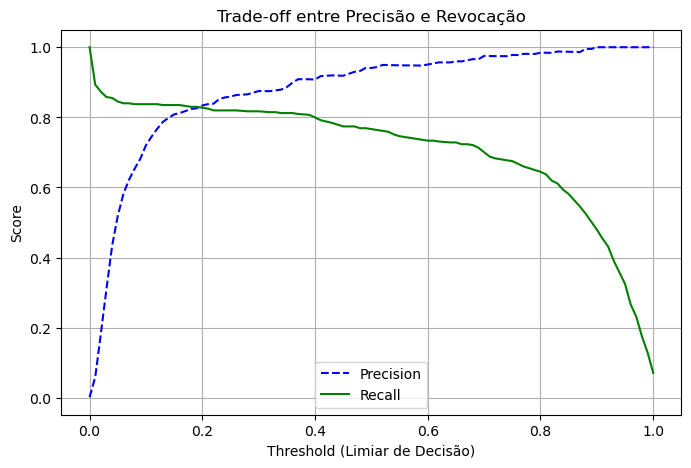

In [16]:
plot_precision_vs_recall(precision, recall, thresholds)

In [17]:
idx_intersection = np.argmin(np.abs(precision[:-1] - recall[:-1]))

print(thresholds[idx_intersection])
print(recall[idx_intersection])

0.19
0.8299492385786802


## Better Model

In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

params =[
    {"ccp_alpha": [0.1, 0.05], "criterion": ["gini", "entropy", "log_loss"], "n_estimators": [100, 150, 200]}
]

grid = GridSearchCV(RandomForestClassifier(class_weight="balanced"), param_grid=params, 
                    scoring="recall", n_jobs=-1, verbose=2, cv=3)

In [19]:
X_prepared = pipeline.fit_transform(X_train)

filename = "models/grid_ran_for.pkl"

# grid.fit(X_prepared, y_train)
# joblib.dump(grid, filename)

grid = joblib.load(filename)
grid

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .ccp_alpha=0.1, criterion=entropy, n_estimators=100; total time= 1.9min
[CV] END .ccp_alpha=0.1, criterion=entropy, n_estimators=150; total time= 3.1min
[CV] END ccp_alpha=0.1, criterion=log_loss, n_estimators=150; total time= 3.6min
[CV] END ccp_alpha=0.05, criterion=entropy, n_estimators=100; total time= 2.3min
[CV] END ccp_alpha=0.05, criterion=log_loss, n_estimators=100; total time= 2.1min
[CV] END .ccp_alpha=0.1, criterion=entropy, n_estimators=100; total time= 2.3min
[CV] END .ccp_alpha=0.1, criterion=entropy, n_estimators=200; total time= 5.0min
[CV] END ...ccp_alpha=0.05, criterion=gini, n_estimators=150; total time= 3.6min
[CV] END ccp_alpha=0.05, criterion=log_loss, n_estimators=100; total time= 2.2min
[CV] END ....ccp_alpha=0.1, criterion=gini, n_estimators=100; total time= 2.1min
[CV] END .ccp_alpha=0.1, criterion=entropy, n_estimators=200; total time= 4.5min
[CV] END ...ccp_alpha=0.05, criterion=gini, n_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'ccp_alpha': [0.1, 0.05], 'criterion': ['gini', 'entropy', ...], 'n_estimators': [100, 150, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [22]:
ran_for_best = grid.best_estimator_

filename = "results/proba_ran_for_best"
# y_pred = cross_val_predict(ran_for_best, X_prepared, y_train,
#                            method='predict_proba')
# joblib.dump(y_pred, filename)

y_proba = joblib.load(filename)[:, 1]
y_pred_class = (y_proba >= 0.50).astype(int)

cm = confusion_matrix(y_train, y_pred_class)
cm

array([[225952,   1499],
       [    58,    336]])

In [28]:
cm[1][1] / (cm[1][1] + cm[1][0]) # analogous to recall_score

np.float64(0.8527918781725888)